# Métricas e Gráficos para análises

## Imports e configs principais

In [1]:
# %pip install pandas numpy seaborn

In [2]:
# Célula 1: Imports e Configurações Iniciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import cv2
from PIL import Image
import os
import json

# Configuração de estilo para os gráficos ficarem mais legíveis
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
# Célula 2: Configuração de Caminhos (Paths)
import os

# Defina o caminho absoluto para a raiz do seu projeto
# Exemplo: '/home/usuario/projetos/meu_modelo' ou 'C:/projetos/meu_modelo'
BASE_DIR = '/home/aluno/Documentos/visaoComputacional/TrabalhoDeVisao'

# Mapeamento dos diretórios essenciais
LOGS_BASELINE = os.path.join(BASE_DIR, 'log_modelo_A.txt')       # Onde estão os históricos (CSV, JSON, etc.)
LOGS_V2 = os.path.join(BASE_DIR, 'log_model_v2.out')
MODEL_BASELINE = os.path.join(BASE_DIR, 'runs/unet_v1/unet_best_v1.pth')   # Onde estão os checkpoints (ex: .pt, .pth)
MODEL_V2 = os.path.join(BASE_DIR, 'runs/unet_v2/unet_best.pth')
OUTPUT_DIR = os.path.join(BASE_DIR, 'notebooks/outputs')  # Onde salvaremos os plots e imagens da análise

# Cria o diretório de saída caso ele ainda não exista
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Altera o diretório de trabalho atual do notebook para a raiz do projeto
os.chdir(BASE_DIR)

In [4]:
# Célula 3: Leitura exploratória dos logs
def ler_amostra_log(caminho_arquivo, num_linhas=10):
    """Lê as últimas linhas do log para entendermos o formato das métricas."""
    try:
        with open(caminho_arquivo, 'r') as f:
            linhas = f.readlines()
            # Pega as últimas N linhas, filtrando linhas vazias se houver
            amostra = [linha.strip() for linha in linhas[-num_linhas:] if linha.strip()]
            
            print(f"--- Últimas linhas de {os.path.basename(caminho_arquivo)} ---")
            for linha in amostra:
                print(linha)
            print("-" * 50 + "\n")
    except FileNotFoundError:
        print(f"⚠️ Arquivo não encontrado: {caminho_arquivo}")

# Espiando o formato de saída de ambos os modelos
ler_amostra_log(LOGS_BASELINE, num_linhas=5)
ler_amostra_log(LOGS_V2, num_linhas=5)

--- Últimas linhas de log_modelo_A.txt ---
Epoch 17/50: 100%|██████████| 8664/8664 [14:14<00:00, 10.14batch/s, loss=0.1359]
Epoch 17 - train_loss=0.2094 - lr=0.001000 - val_loss=0.2619 - val_iou=0.6069 - val_dice=0.6403
No improvement for 7/7 epochs
Early stopping at epoch 17 (best val_loss=0.2465)
Final model saved to: runs/unet/unet_final.pth
--------------------------------------------------

--- Últimas linhas de log_model_v2.out ---
Epoch 48/100: 100%|██████████| 2166/2166 [16:48<00:00,  2.15batch/s, loss=0.1057]
Epoch 48 - train_loss=0.1674 - lr=0.000846 - val_loss=0.2892 - val_iou=0.6037 - val_dice=0.6640
No improvement for 15/15 epochs
Early stopping at epoch 48 (best iou=0.6283)
Final model saved to: runs/unet_v2/unet_v2_final.pth
--------------------------------------------------



In [5]:
# Célula 5: Inspeção do formato dos logs de treinamento
def inspecionar_log(caminho, num_linhas=10):
    print(f"\n{'='*50}")
    print(f"--- Inspecionando: {caminho} ---")
    print(f"{'='*50}")
    try:
        with open(caminho, 'r') as f:
            linhas = f.readlines()
            # Remove quebras de linha e filtra linhas vazias
            linhas_limpas = [l.strip() for l in linhas if l.strip()]
            
            if not linhas_limpas:
                print("⚠️ O arquivo está vazio.")
                return
            
            print("[PRIMEIRAS LINHAS]")
            for linha in linhas_limpas[:num_linhas]:
                print(linha)
                
            print("\n[ÚLTIMAS LINHAS]")
            for linha in linhas_limpas[-num_linhas:]:
                print(linha)
                
    except FileNotFoundError:
        print(f"⚠️ Erro: Arquivo não encontrado no caminho:\n{caminho}")
    except Exception as e:
        print(f"⚠️ Erro inesperado ao ler o arquivo: {e}")

# Executa a inspeção para a V1 e V2
inspecionar_log(LOGS_BASELINE)
inspecionar_log(LOGS_V2)


--- Inspecionando: /home/aluno/Documentos/visaoComputacional/TrabalhoDeVisao/log_modelo_A.txt ---
[PRIMEIRAS LINHAS]
nohup: ignorando entrada
Device: cuda
Train samples: 8664
Val samples: 2175
Parameters: 31,030,658
Early stopping: patience=7 epochs
Epoch 1/50:   0%|          | 1/8664 [00:00<44:53,  3.22batch/s, loss=0.0795]

[ÚLTIMAS LINHAS]
Epoch 17/50: 100%|██████████| 8664/8664 [14:14<00:00, 10.14batch/s, loss=0.1359]
Epoch 17 - train_loss=0.2094 - lr=0.001000 - val_loss=0.2619 - val_iou=0.6069 - val_dice=0.6403
No improvement for 7/7 epochs
Early stopping at epoch 17 (best val_loss=0.2465)
Final model saved to: runs/unet/unet_final.pth

--- Inspecionando: /home/aluno/Documentos/visaoComputacional/TrabalhoDeVisao/log_model_v2.out ---
[PRIMEIRAS LINHAS]
nohup: ignorando entrada
Device: cuda
Model: v2 (padding=same)
Optimizer: adamw | Loss: combined (dice_weight=0.5)
Scheduler: batch (OneCycleLR)
Train samples: 8664
Val samples: 2175
Parameters: 31,036,546
Augmentation: ['elastic', 

In [6]:
# Célula 6: Extração de métricas dos logs
import re
import pandas as pd

def extrair_historico(caminho_log):
    """Lê o arquivo de log e extrai as métricas usando expressões regulares."""
    dados = []
    
    # Padrão Regex para capturar os valores da linha de resumo da época
    # Ex: Epoch 17 - train_loss=0.2094 - lr=0.001000 - val_loss=0.2619 - val_iou=0.6069 - val_dice=0.6403
    padrao = re.compile(r"Epoch (\d+) - train_loss=([\d\.]+) - lr=([\d\.]+) - val_loss=([\d\.]+) - val_iou=([\d\.]+) - val_dice=([\d\.]+)")
    
    with open(caminho_log, 'r') as f:
        for linha in f:
            match = padrao.search(linha)
            if match:
                dados.append({
                    'epoch': int(match.group(1)),
                    'train_loss': float(match.group(2)),
                    'lr': float(match.group(3)),
                    'val_loss': float(match.group(4)),
                    'val_iou': float(match.group(5)),
                    'val_dice': float(match.group(6))
                })
                
    return pd.DataFrame(dados)

# Criando os DataFrames para ambos os modelos
df_v1 = extrair_historico(LOGS_BASELINE)
df_v2 = extrair_historico(LOGS_V2)

print("Dados da V1 (Baseline):")
display(df_v1.tail(3))
print("\nDados da V2:")
display(df_v2.tail(3))

Dados da V1 (Baseline):


,epoch,train_loss,lr,val_loss,val_iou,val_dice
14,15,0.2100,0.001,0.2659,0.6032,0.6356
15,16,0.2104,0.001,0.2777,0.6073,0.6400
16,17,0.2094,0.001,0.2619,0.6069,0.6403



Dados da V2:


,epoch,train_loss,lr,val_loss,val_iou,val_dice
45,46,0.1744,0.000877,0.2780,0.6007,0.6620
46,47,0.1682,0.000861,0.2705,0.5994,0.6652
47,48,0.1674,0.000846,0.2892,0.6037,0.6640


## Baseline

### Métricas de treinamento

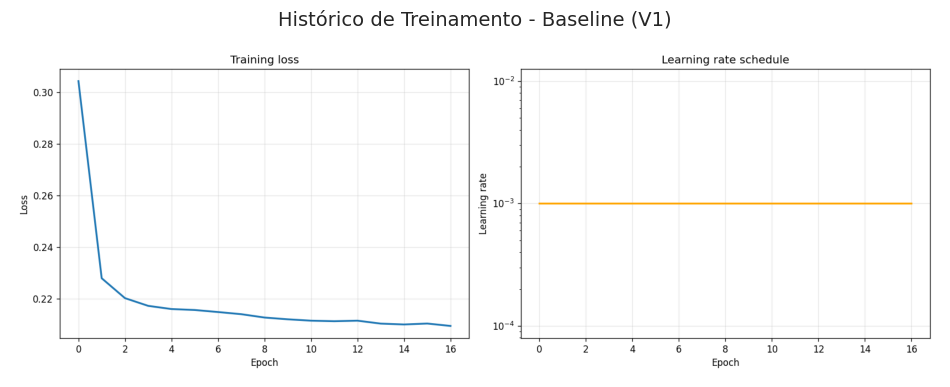

In [7]:
# Célula 4: Visualização do Gráfico de Histórico de Treinamento (Baseline V1)
import os
from PIL import Image
import matplotlib.pyplot as plt

# Monta o caminho completo usando a BASE_DIR definida na Célula 2
caminho_grafico_v1 = os.path.join(BASE_DIR, 'runs/unet_v1/training_history.png')

if os.path.exists(caminho_grafico_v1):
    # Carrega a imagem
    img = Image.open(caminho_grafico_v1)
    
    # Configura a exibição do plot
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')  # Remove as réguas de pixel (eixos X e Y) para limpar o visual
    plt.title("Histórico de Treinamento - Baseline (V1)", fontsize=14, pad=15)
    plt.show()
else:
    print(f"⚠️ O arquivo não foi encontrado no caminho especificado:\n{caminho_grafico_v1}")
    print("Verifique se o nome do arquivo ou a estrutura de pastas possui alguma divergência.")

Gráfico do Baseline salvo em: /home/aluno/Documentos/visaoComputacional/TrabalhoDeVisao/notebooks/outputs/historico_baseline_v1.png


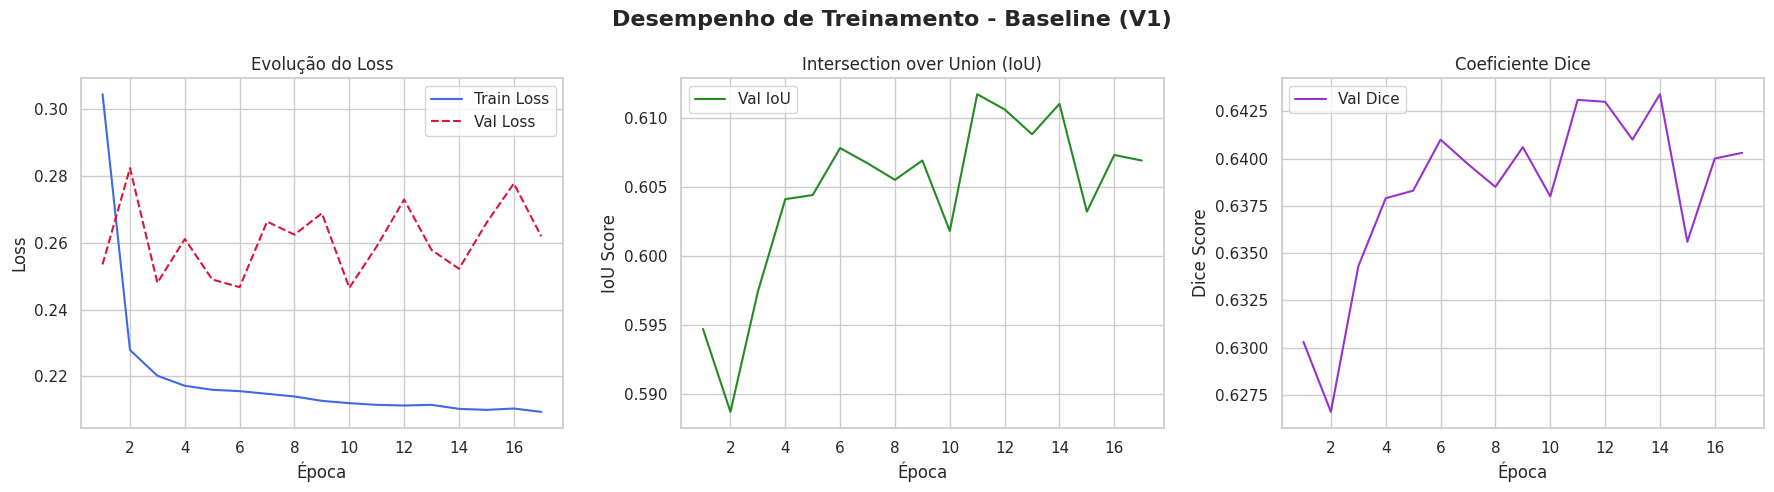

In [8]:
# Célula 10: Gráficos de Desempenho - Baseline (V1)
import matplotlib.pyplot as plt
import os

# Cria uma figura com 3 subplots para o Baseline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Desempenho de Treinamento - Baseline (V1)', fontsize=16, fontweight='bold')

# --- Gráfico 1: Train Loss vs Val Loss ---
axes[0].plot(df_v1['epoch'], df_v1['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(df_v1['epoch'], df_v1['val_loss'], label='Val Loss', color='crimson', linestyle='--')
axes[0].set_title('Evolução do Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# --- Gráfico 2: Validation IoU ---
axes[1].plot(df_v1['epoch'], df_v1['val_iou'], label='Val IoU', color='forestgreen')
axes[1].set_title('Intersection over Union (IoU)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('IoU Score')
axes[1].legend()

# --- Gráfico 3: Validation Dice ---
axes[2].plot(df_v1['epoch'], df_v1['val_dice'], label='Val Dice', color='darkorchid')
axes[2].set_title('Coeficiente Dice')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Dice Score')
axes[2].legend()

plt.tight_layout()

# Salva o gráfico
caminho_v1 = os.path.join(OUTPUT_DIR, 'historico_baseline_v1.png')
plt.savefig(caminho_v1, dpi=300, bbox_inches='tight')
print(f"Gráfico do Baseline salvo em: {caminho_v1}")

plt.show()

In [9]:
# Célula 8: Resumo de Métricas - Baseline (V1)
print(f"{'='*40}")
print(" MÉTRICAS DETALHADAS - BASELINE (V1)")
print(f"{'='*40}")

# Encontra a linha com o melhor Val Loss (critério de parada do Baseline)
idx_best_loss_v1 = df_v1['val_loss'].idxmin()
best_epoch_v1 = df_v1.loc[idx_best_loss_v1]

print(f"Época com melhor Validation Loss: {int(best_epoch_v1['epoch'])}")
print(f"-> Train Loss:      {best_epoch_v1['train_loss']:.4f}")
print(f"-> Validation Loss: {best_epoch_v1['val_loss']:.4f} (Melhor)")
print(f"-> Validation IoU:  {best_epoch_v1['val_iou']:.4f}")
print(f"-> Validation Dice: {best_epoch_v1['val_dice']:.4f}")
print(f"-> Learning Rate:   {best_epoch_v1['lr']:.6f}")

print("\nÚltimas 3 épocas registradas no log:")
display(df_v1.tail(3))

 MÉTRICAS DETALHADAS - BASELINE (V1)
Época com melhor Validation Loss: 10
-> Train Loss:      0.2120
-> Validation Loss: 0.2465 (Melhor)
-> Validation IoU:  0.6018
-> Validation Dice: 0.6380
-> Learning Rate:   0.001000

Últimas 3 épocas registradas no log:


,epoch,train_loss,lr,val_loss,val_iou,val_dice
14,15,0.2100,0.001,0.2659,0.6032,0.6356
15,16,0.2104,0.001,0.2777,0.6073,0.6400
16,17,0.2094,0.001,0.2619,0.6069,0.6403


## Model V1

### Métricas de treinamento

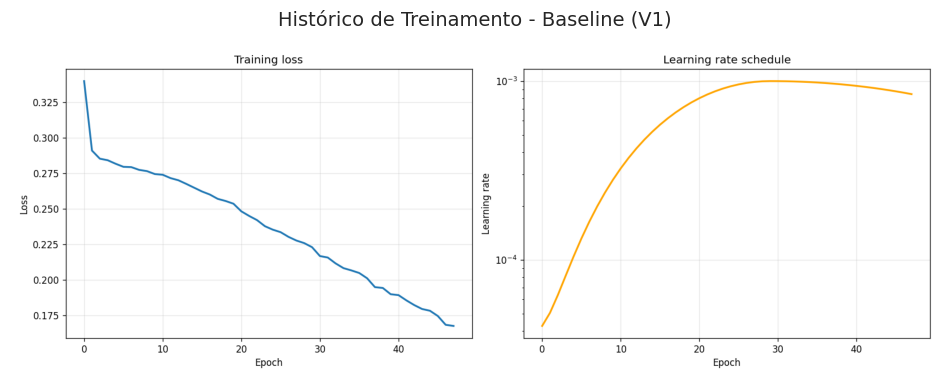

In [10]:
# Célula 4: Visualização do Gráfico de Histórico de Treinamento (Baseline V1)
import os
from PIL import Image
import matplotlib.pyplot as plt

# Monta o caminho completo usando a BASE_DIR definida na Célula 2
caminho_grafico_v1 = os.path.join(BASE_DIR, 'runs/unet_v2/training_history.png')

if os.path.exists(caminho_grafico_v1):
    # Carrega a imagem
    img = Image.open(caminho_grafico_v1)
    
    # Configura a exibição do plot
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')  # Remove as réguas de pixel (eixos X e Y) para limpar o visual
    plt.title("Histórico de Treinamento - Baseline (V1)", fontsize=14, pad=15)
    plt.show()
else:
    print(f"⚠️ O arquivo não foi encontrado no caminho especificado:\n{caminho_grafico_v1}")
    print("Verifique se o nome do arquivo ou a estrutura de pastas possui alguma divergência.")

Gráfico da V2 salvo em: /home/aluno/Documentos/visaoComputacional/TrabalhoDeVisao/notebooks/outputs/historico_modelo_v2.png


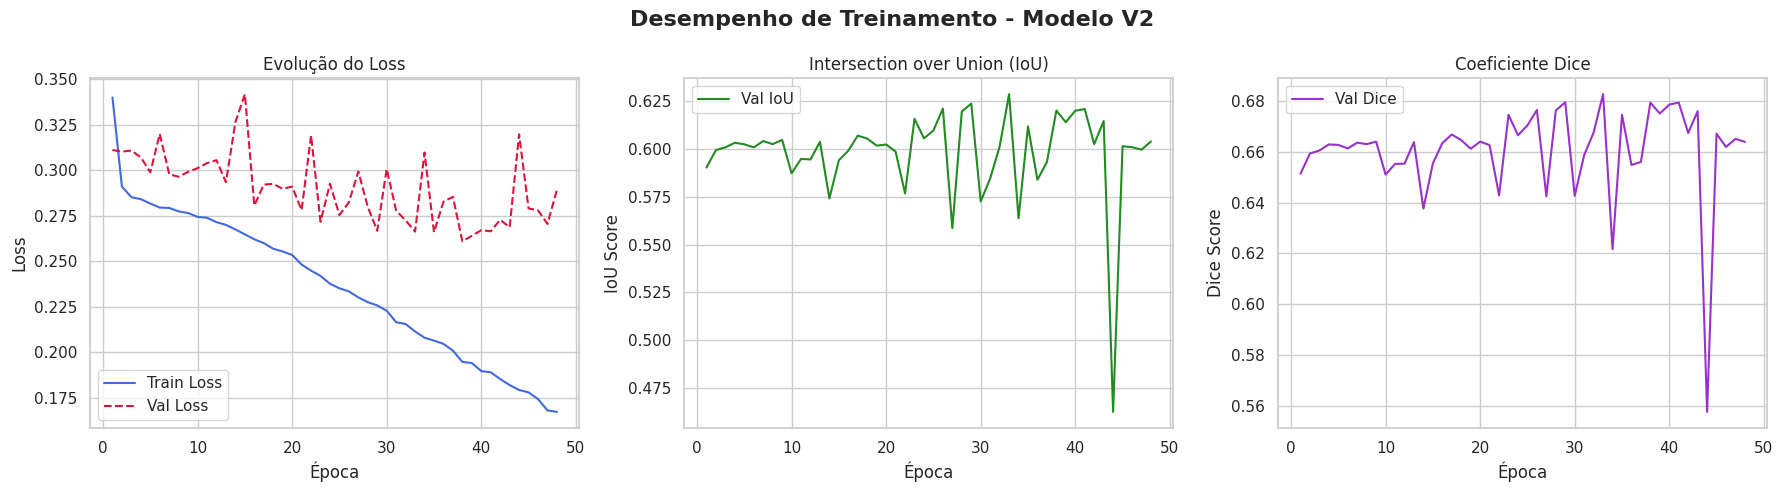

In [11]:
# Célula 11: Gráficos de Desempenho - Modelo V2
import matplotlib.pyplot as plt
import os

# Cria uma figura com 3 subplots para a V2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Desempenho de Treinamento - Modelo V2', fontsize=16, fontweight='bold')

# --- Gráfico 1: Train Loss vs Val Loss ---
axes[0].plot(df_v2['epoch'], df_v2['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(df_v2['epoch'], df_v2['val_loss'], label='Val Loss', color='crimson', linestyle='--')
axes[0].set_title('Evolução do Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# --- Gráfico 2: Validation IoU ---
axes[1].plot(df_v2['epoch'], df_v2['val_iou'], label='Val IoU', color='forestgreen')
axes[1].set_title('Intersection over Union (IoU)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('IoU Score')
axes[1].legend()

# --- Gráfico 3: Validation Dice ---
axes[2].plot(df_v2['epoch'], df_v2['val_dice'], label='Val Dice', color='darkorchid')
axes[2].set_title('Coeficiente Dice')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Dice Score')
axes[2].legend()

plt.tight_layout()

# Salva o gráfico
caminho_v2 = os.path.join(OUTPUT_DIR, 'historico_modelo_v2.png')
plt.savefig(caminho_v2, dpi=300, bbox_inches='tight')
print(f"Gráfico da V2 salvo em: {caminho_v2}")

plt.show()

In [12]:
# Célula 9: Resumo de Métricas - Modelo V2
print(f"{'='*40}")
print(" MÉTRICAS DETALHADAS - MODELO V2")
print(f"{'='*40}")

# Encontra a linha com o melhor Val IoU (critério de parada da V2)
idx_best_iou_v2 = df_v2['val_iou'].idxmax()
best_epoch_v2 = df_v2.loc[idx_best_iou_v2]

print(f"Época com melhor Validation IoU: {int(best_epoch_v2['epoch'])}")
print(f"-> Train Loss:      {best_epoch_v2['train_loss']:.4f}")
print(f"-> Validation Loss: {best_epoch_v2['val_loss']:.4f}")
print(f"-> Validation IoU:  {best_epoch_v2['val_iou']:.4f} (Melhor)")
print(f"-> Validation Dice: {best_epoch_v2['val_dice']:.4f}")
print(f"-> Learning Rate:   {best_epoch_v2['lr']:.6f}")

print("\nÚltimas 3 épocas registradas no log:")
display(df_v2.tail(3))

 MÉTRICAS DETALHADAS - MODELO V2
Época com melhor Validation IoU: 33
-> Train Loss:      0.2115
-> Validation Loss: 0.2663
-> Validation IoU:  0.6283 (Melhor)
-> Validation Dice: 0.6828
-> Learning Rate:   0.000995

Últimas 3 épocas registradas no log:


,epoch,train_loss,lr,val_loss,val_iou,val_dice
45,46,0.1744,0.000877,0.2780,0.6007,0.6620
46,47,0.1682,0.000861,0.2705,0.5994,0.6652
47,48,0.1674,0.000846,0.2892,0.6037,0.6640


## Comparação

 COMPARAÇÃO FINAL DE DESEMPENHO (MÉTRICAS EM %)

Métrica: IOU
  - Baseline (V1) : 60.22%
  - Modelo V2     : 60.66%
  🏆 Vencedor     : Modelo V2 (+0.44%)
--------------------------------------------------
Métrica: DICE
  - Baseline (V1) : 63.84%
  - Modelo V2     : 66.70%
  🏆 Vencedor     : Modelo V2 (+2.86%)
--------------------------------------------------
Métrica: ACCURACY
  - Baseline (V1) : 87.95%
  - Modelo V2     : 89.43%
  🏆 Vencedor     : Modelo V2 (+1.48%)
--------------------------------------------------

📊 Gráfico de barras salvo em: /home/aluno/Documentos/visaoComputacional/TrabalhoDeVisao/notebooks/outputs/comparacao_metricas_finais.png


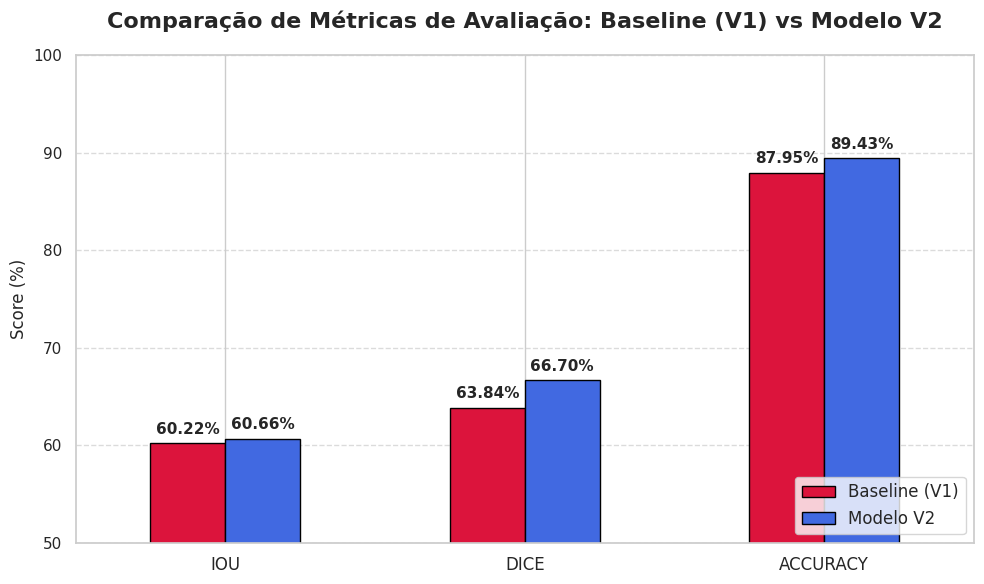

In [13]:
# Célula 12: Comparação de Métricas Finais de Avaliação (CORRIGIDA)
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Definindo os caminhos dos arquivos JSON de métricas
path_metrics_v1 = os.path.join(BASE_DIR, 'runs/unet_v1/eval/metrics.json')
path_metrics_v2 = os.path.join(BASE_DIR, 'runs/unet_v2/eval/metrics.json')

def carregar_metricas(caminho):
    """Carrega as métricas de um arquivo JSON."""
    if os.path.exists(caminho):
        with open(caminho, 'r') as f:
            return json.load(f)
    else:
        print(f"⚠️ Arquivo não encontrado: {caminho}")
        return None

# Carregando os dicionários
metrics_v1 = carregar_metricas(path_metrics_v1)
metrics_v2 = carregar_metricas(path_metrics_v2)

if metrics_v1 and metrics_v2:
    # Transformando em DataFrame para organizar os dados
    df_metrics = pd.DataFrame([metrics_v1, metrics_v2], index=['Baseline (V1)', 'Modelo V2'])
    
    # Selecionando apenas as métricas principais e convertendo para porcentagem
    cols_interesse = ['iou', 'dice', 'accuracy']
    df_plot = df_metrics[cols_interesse] * 100
    
    # Renomeando as colunas para maiúsculo para o gráfico ficar elegante
    df_plot.columns = [col.upper() for col in df_plot.columns]
    
    print(f"{'='*50}")
    print(" COMPARAÇÃO FINAL DE DESEMPENHO (MÉTRICAS EM %)")
    print(f"{'='*50}\n")
    
    # Imprimindo o vencedor de cada métrica
    for col in df_plot.columns:
        val_v1 = df_plot.loc['Baseline (V1)', col]
        val_v2 = df_plot.loc['Modelo V2', col]
        
        vencedor = 'Modelo V2' if val_v2 > val_v1 else 'Baseline (V1)'
        ganho = abs(val_v2 - val_v1)
        
        print(f"Métrica: {col}")
        print(f"  - Baseline (V1) : {val_v1:.2f}%")
        print(f"  - Modelo V2     : {val_v2:.2f}%")
        print(f"  🏆 Vencedor     : {vencedor} (+{ganho:.2f}%)")
        print("-" * 50)
        
    # --- Plotando o Gráfico de Barras ---
    # Transpondo o DataFrame para o eixo X ser a métrica e as barras os modelos
    ax = df_plot.T.plot(kind='bar', figsize=(10, 6), color=['crimson', 'royalblue'], edgecolor='black')
    
    plt.title('Comparação de Métricas de Avaliação: Baseline (V1) vs Modelo V2', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Score (%)', fontsize=12)
    
    # Rotação ajustada e sem o argumento inválido
    plt.xticks(rotation=0, fontsize=12)
    
    # Ajustando o limite do eixo Y para destacar as diferenças (de 50 a 100)
    plt.ylim(50, 100)
    
    # Adicionando os valores exatos em cima de cada barra
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')
                    
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Salvando a imagem
    caminho_salvamento = os.path.join(OUTPUT_DIR, 'comparacao_metricas_finais.png')
    plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
    print(f"\n📊 Gráfico de barras salvo em: {caminho_salvamento}")
    
    plt.show()

Dispositivo de inferência: cuda
Carregando arquiteturas e pesos...
Modelos instanciados e prontos para inferência.


✅ Painel de inferência salvo com sucesso em: /home/aluno/Documentos/visaoComputacional/TrabalhoDeVisao/notebooks/outputs/inferencia_comparativa_testes.png


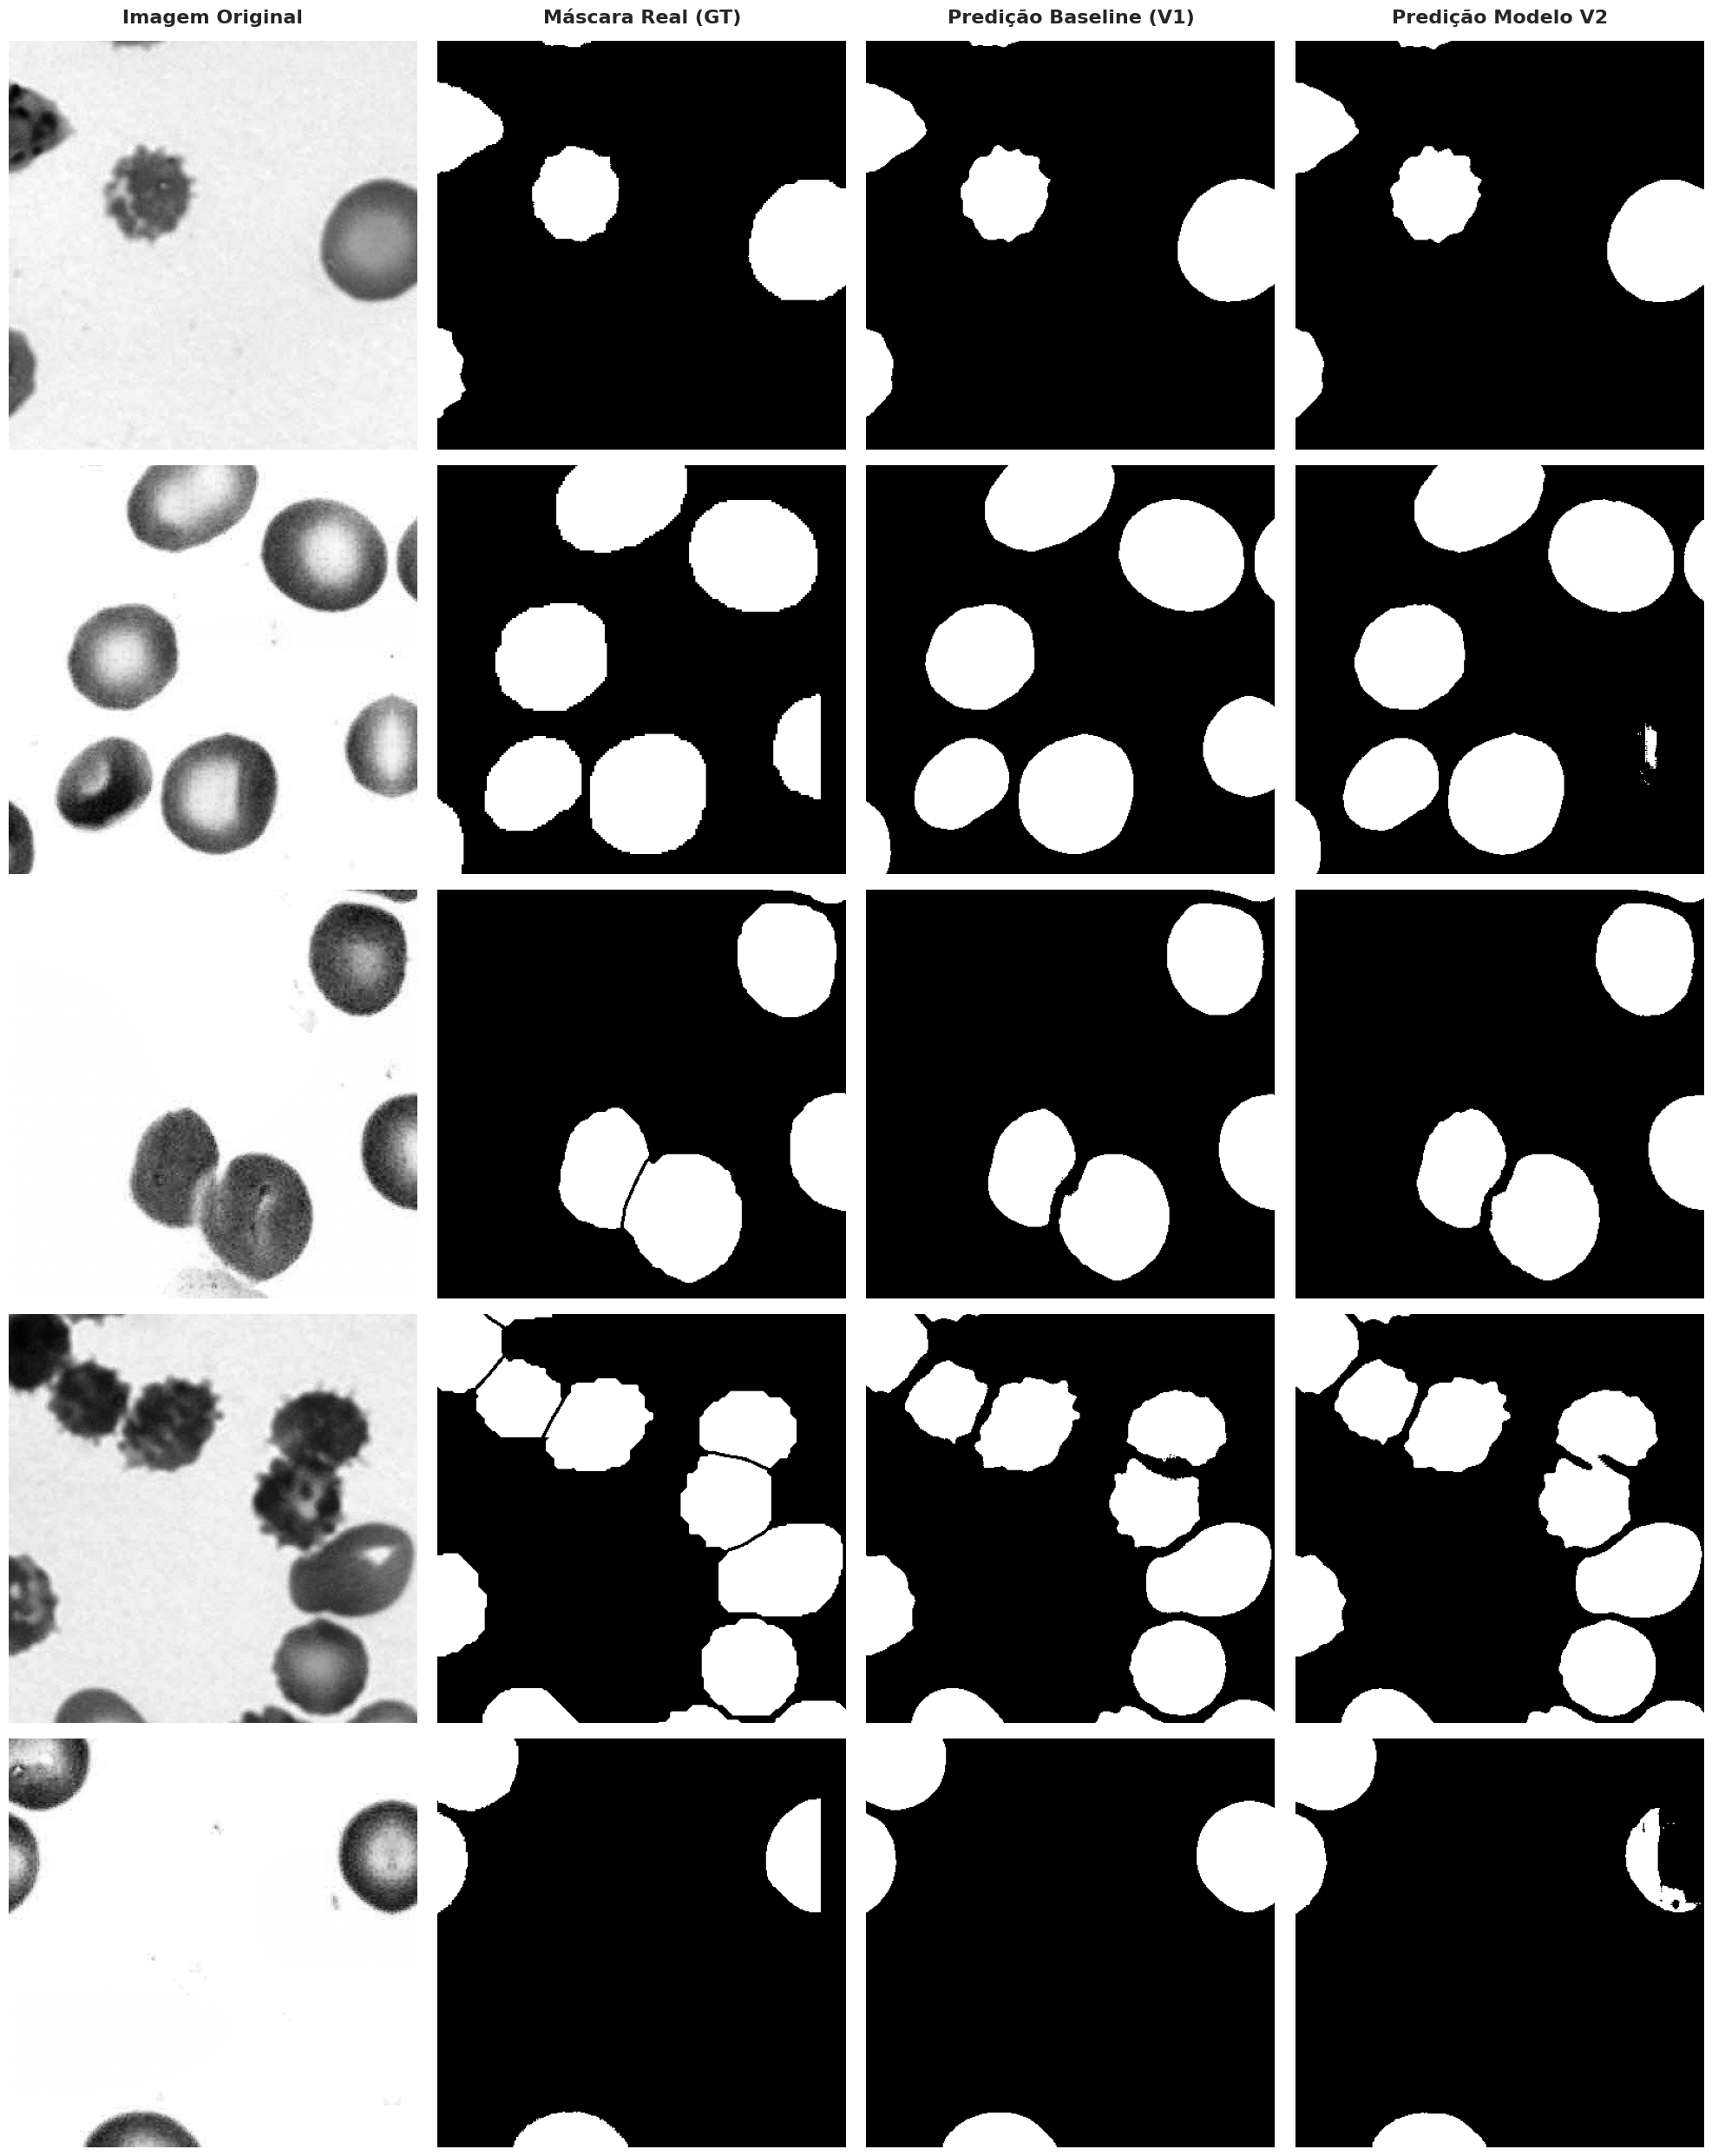

In [21]:
# Célula 13: Inferência Visual (Alinhada com evaluate.py)
import os
import sys
import random
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURAÇÃO DE DIRETÓRIOS E PATH ---
BASE_DIR = '/home/aluno/Documentos/visaoComputacional/TrabalhoDeVisao'
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)  # Garante que o notebook encontre os módulos do projeto

MODEL_BASELINE_PATH = os.path.join(BASE_DIR, 'runs/unet_v1/unet_best_v1.pth')
MODEL_V2_PATH = os.path.join(BASE_DIR, 'runs/unet_v2/unet_best.pth')

IMG_TEST_DIR = os.path.join(BASE_DIR, 'data/BCCD_processado/test/original_tiles')
MASK_TEST_DIR = os.path.join(BASE_DIR, 'data/BCCD_processado/test/mask_tiles')
OUTPUT_DIR = os.path.join(BASE_DIR, 'notebooks/outputs')

# --- 2. IMPORTAÇÃO E CARREGAMENTO DOS MODELOS ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de inferência: {device}")
print("Carregando arquiteturas e pesos...")

# Importando diretamente dos seus arquivos locais (model.py e model_v2.py)
from unet_bccd.model import UNet
from unet_bccd.model_v2 import UNetV2

# Instanciando com as configurações reveladas no evaluate.py
model_baseline = UNet(in_channels=1, out_channels=2).to(device)
model_v2 = UNetV2(in_channels=1, out_channels=2, padding=1).to(device)

# Carregando os dicionários de pesos
model_baseline.load_state_dict(torch.load(MODEL_BASELINE_PATH, map_location=device))
model_v2.load_state_dict(torch.load(MODEL_V2_PATH, map_location=device))

model_baseline.eval()
model_v2.eval()
print("Modelos instanciados e prontos para inferência.\n")

# --- 3. FUNÇÃO AUXILIAR DE RECORTE ---
def center_crop_numpy(img_array, target_h, target_w):
    """Recorta o centro de um array numpy para alinhar com o tamanho da predição."""
    h, w = img_array.shape[:2]
    start_h = (h - target_h) // 2
    start_w = (w - target_w) // 2
    return img_array[start_h : start_h + target_h, start_w : start_w + target_w]

# --- 4. PREPARAÇÃO DOS DADOS ---
todas_imagens = [f for f in os.listdir(IMG_TEST_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]

if len(todas_imagens) < 5:
    print(f"⚠️ Não há 5 imagens suficientes na pasta: {IMG_TEST_DIR}")
else:
    imagens_sorteadas = random.sample(todas_imagens, 5)

    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    # --- 5. INFERÊNCIA E PLOTAGEM ---
    fig, axes = plt.subplots(5, 4, figsize=(20, 25))
    titulos = ['Imagem Original', 'Máscara Real (GT)', 'Predição Baseline (V1)', 'Predição Modelo V2']
    
    for ax, titulo in zip(axes[0], titulos):
        ax.set_title(titulo, fontsize=16, fontweight='bold', pad=15)

    for i, img_nome in enumerate(imagens_sorteadas):
        img_path = os.path.join(IMG_TEST_DIR, img_nome)
        mask_path = os.path.join(MASK_TEST_DIR, img_nome) 
        
        # IMPORTANTE: Carregando como escala de cinza ('L') para in_channels=1
        img_pil = Image.open(img_path).convert('L')
        mask_pil = Image.open(mask_path).convert('L') 
        
        img_tensor = transform(img_pil).unsqueeze(0).to(device) 
        
        with torch.no_grad():
            output_baseline = model_baseline(img_tensor)
            output_v2 = model_v2(img_tensor)
            
            # Usando argmax (dim=1) devido ao out_channels=2
            pred_baseline = torch.argmax(output_baseline, dim=1).squeeze().cpu().numpy()
            pred_v2 = torch.argmax(output_v2, dim=1).squeeze().cpu().numpy()

        # Extraindo as dimensões preditas para recortar as imagens originais
        target_h, target_w = pred_baseline.shape
        
        img_np = np.array(img_pil)
        mask_np = np.array(mask_pil)
        
        # Alinhando as dimensões se o modelo não usar padding
        if img_np.shape != (target_h, target_w):
            img_np = center_crop_numpy(img_np, target_h, target_w)
            mask_np = center_crop_numpy(mask_np, target_h, target_w)
            
            # Recorta também a predição da v2 caso ela seja maior que a do baseline
            if pred_v2.shape != (target_h, target_w):
                pred_v2 = center_crop_numpy(pred_v2, target_h, target_w)

        # Plotando (tudo em cmap='gray' pois são dados mono-canal)
        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_baseline, cmap='gray')
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(pred_v2, cmap='gray')
        axes[i, 3].axis('off')

    plt.tight_layout()
    
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    caminho_salvamento = os.path.join(OUTPUT_DIR, 'inferencia_comparativa_testes.png')
    plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
    print(f"\n✅ Painel de inferência salvo com sucesso em: {caminho_salvamento}")
    
    plt.show()